# Synthetic recovery map example

This notebook illustrates how to use `detectability_map_from_series_parallel` in **RAVEX** to compute a recovery map in the orbital-period vs. minimum-mass plane.

## What is a recovery map?

A recovery map quantifies how detectable additional planetary signals are in a given radial-velocity (RV) time series. For each point in a user-defined grid of orbital period and $M\sin i$, the function:

1. injects a synthetic Keplerian signal into the input RV series,
2. repeats the injection over multiple orbital phases,
3. searches for the dominant periodicity with a generalized Lomb-Scargle periodogram,
4. evaluates whether the injected signal is successfully recovered.

The final map is therefore a measure of **detectability** as a function of period and mass.

In this example, we start from a **synthetic noise-only RV dataset** generated with RAVEX. The observing times are randomly distributed over a fixed time span, and the noise level is chosen to mimic CARMENES-like observations of a quiet M dwarf. We adopt an instrumental RV uncertainty from `carm_error(...)` and include an additional stellar jitter term in quadrature.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.time as t
import time
from ravex import MultiPlanetSystem, plot_detectability_map, carm_error

In [2]:
mass_star = 0.50 * u.solMass

system = MultiPlanetSystem(
    mass_main=mass_star,
    planets=[]
)

In [3]:
n_obs = 60
span_days = 120
start_time = t.Time("2026-01-01T00:00:00", format="isot", scale="utc")

rng = np.random.default_rng(42)

obs_dates = system.obs_dates(
    n_obs=n_obs,
    span_days=span_days,
    date_one=start_time,
    rng=rng
)

In [4]:
# Let's assume that our observations are conducted with CARMENES, and the target star is a quiet M1 (Jmag=8)
sigma_carm = carm_error(
    jmag=8.00,
    spt=1,
    vsini=1.5
)

# Assume an additional astrophysical jitter valid for quiet M-dwarfs (Ruh et al. 2025)
sigma_jitter = 2.5  # m/s

# Total per-measurement uncertainty
sigma_eff = np.sqrt(sigma_carm**2 + sigma_jitter**2) * u.m/u.s

print(f"CARMENES-like instrumental error: {sigma_carm:.3f} m/s")
print(f"Assumed stellar jitter: {sigma_jitter:.3f} m/s")
print(f"Total RV uncertainty per measurement: {sigma_eff.to_value(u.m/u.s):.3f} m/s")

# Synthetic RV serie without planets
jd, rv, phases, phased = system.get_rvs(
    obs_dates,
    noise=sigma_eff,
    rng=rng
)

# Uncertainty per point 
rv_err = np.full_like(rv, sigma_eff.to_value(u.m/u.s), dtype=float)
rv_err_plot = np.full_like(rv, sigma_carm, dtype=float)

CARMENES-like instrumental error: 1.370 m/s
Assumed stellar jitter: 2.500 m/s
Total RV uncertainty per measurement: 2.851 m/s


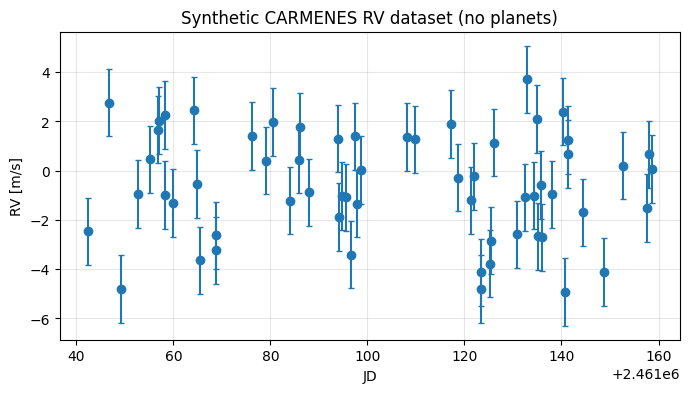

In [5]:
plt.figure(figsize=(8,4))
plt.errorbar(jd, rv, yerr=rv_err_plot, fmt='o', capsize=2)
plt.xlabel("JD")
plt.ylabel("RV [m/s]")
plt.title("Synthetic CARMENES RV dataset (no planets)")
plt.grid(alpha=0.3)
plt.show()

In [6]:
# =========================
# Recovery Map
# =========================

period_grid = np.logspace(np.log10(1.0), np.log10(100.0), 50)   # days
msini_grid = np.logspace(np.log10(0.3), np.log10(20.0), 50)     # M_earth
n_phase = 50

print("Full grid:")
print("  N_periods =", len(period_grid))
print("  N_masses  =", len(msini_grid))
print("  n_phase   =", n_phase)
print("  total recoveries =", len(period_grid) * len(msini_grid) * n_phase)

t0 = time.perf_counter()

res_map = system.detectability_map_from_series_parallel(
    ts=jd,
    rv=rv,
    rv_err=rv_err,
    period_grid=period_grid,
    msini_grid=msini_grid,
    n_phase=n_phase,
    phase_mode='grid',
    eccentricity=0.0,
    criterion='period+fap',
    period_tol=0.25,
    fap_alpha=0.01,
    min_period_search=0.8,
    max_period_search=100.0,
    fap_method='baluev',
    rng_seed=42,
    n_jobs=32,
    chunksize=1,
    mp_start_method="fork",
    verbose=True
)

t1 = time.perf_counter()

print(f"\nTiempo total paralelo: {t1 - t0:.3f} s")

Full grid:
  N_periods = 50
  N_masses  = 50
  n_phase   = 50
  total recoveries = 125000
[detectability_map_parallel] tasks=2500, n_jobs=32, chunksize=1

Tiempo total paralelo: 34.633 s


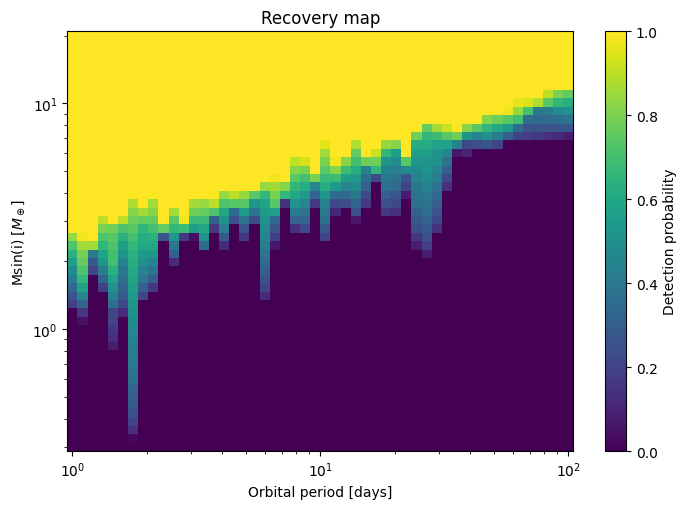

In [7]:
plot_detectability_map(
    res_map,
    key='recovery_rate',
    cbar_label='Detection probability',
    title='Recovery map'
)
plt.show()

## Practical notes and recommendations

The appearance and scientific meaning of a recovery map depend directly on the configuration adopted for the injections and the recovery test. A few practical considerations are worth keeping in mind:

### Grid resolution

The choice of `period_grid` and `msini_grid` controls the resolution of the map.

- A **coarser grid** is faster and is usually a good choice for quick tests, tutorials, and exploratory runs.
- A **finer grid** provides a smoother and more detailed map, but it increases the computational cost substantially.

Since the total runtime scales with the number of grid cells and with the number of tested phases, increasing the resolution in both dimensions can quickly make the calculation expensive. A good strategy is to start with a modest grid to identify the main structure of the map, and then refine the region of interest if needed.

### Number of tested phases

The parameter `n_phase` sets how many orbital phases are explored at each grid cell.

- Lower values run faster, but the map may appear noisier.
- Higher values provide a more stable estimate of the recovery fraction, especially when the observing window function is important.

In general, `n_phase` should be large enough to average over phase-dependent effects, but not so large that the calculation becomes unnecessarily slow.

### Phase sampling mode

The `phase_mode` parameter controls how orbital phases are sampled:

- `'grid'`: phases are evenly spaced between 0 and 1.
- `'random'`: phases are randomly drawn.

The grid mode is often preferable for reproducible and pedagogical examples, while random sampling can be useful in more exploratory studies.

### Recovery criterion

The `criterion` parameter determines how strict the recovery condition is.

- `'period_only'` checks only whether the recovered dominant period is close to the injected one.
- `'period+fap'` also requires the recovered signal to pass a false-alarm-probability threshold.
- `'period+k'` also checks whether the recovered semi-amplitude is consistent with the injected one.
- `'period+fap+k'` is the most restrictive option and combines all conditions.

The stricter the criterion, the lower the recovery rate will generally be. Therefore, the interpretation of the map always depends on the chosen recovery definition.

### Search range and FAP estimation

The periodogram search interval can be controlled through `min_period_search` and `max_period_search`. Restricting the search range can reduce ambiguities and speed up the calculation, while wider ranges are more conservative and realistic.

The false alarm probability can be estimated with:

- `'baluev'`: fast and convenient, usually a good default choice,
- `'bootstrap'`: more computationally expensive, but potentially more robust in some cases.

### Parallel execution

The function `detectability_map_from_series_parallel` can distribute grid cells over multiple CPU cores through `n_jobs`.

- Using more cores can greatly reduce runtime.
- However, very large grids combined with high `n_phase` values can still be expensive.

### Using the results for custom visualizations

The output of `detectability_map_from_series_parallel` is a standard Python dictionary containing the full grids and all derived quantities. This means that users are not restricted to the built-in plotting helper.

For example, the returned dictionary includes arrays such as:

- `period_grid_days`
- `msini_grid_mearth`
- `recovery_rate`
- `period_hit_rate`
- `median_fap`
- `median_sigma`
- `median_k_relerr`
- `median_p_best_days`

These can be accessed directly and used to build fully custom visualizations with `matplotlib`, `pcolormesh`, `contourf`, `imshow`, or any other preferred plotting tool. This is particularly useful if the user wants to:

- overplot detection thresholds or theoretical curves,
- highlight specific regions of parameter space,
- compare several maps side by side,
- adapt labels, color scales, annotations, or contour levels,
- or integrate the map into a publication-quality figure with a custom layout.

The provided plotting function is therefore best understood as a convenient default visualization tool, not as a mandatory part of the workflow.

### Final recommendation

A recovery map should usually be built iteratively:

1. start with a moderate grid and a modest number of phases,
2. inspect the global structure of the map,
3. refine the grid or increase `n_phase` only if more detail is needed.

This approach makes the analysis both faster and easier to interpret.